# Цель: разработать модель бинарной классификации для прогнозирования выживаемости пассажиров "Титаника"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Titanic-Dataset.csv')

## Первичный осмотр датасета

Для начала рассмотрим какие столбцы есть в датасете, их типы и наличие пропусков

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Типы данных корретны  
Есть пропуски в столбцах Age, Cabin, Embarked

In [7]:
for i in ('Age', 'Cabin', 'Embarked'):
    print(f'Пропусков в столбце {i}: {df[i].isna().sum()}')

Пропусков в столбце Age: 177
Пропусков в столбце Cabin: 687
Пропусков в столбце Embarked: 2


Проверим как распределены данные по столбцам

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Судя по описательной статистике, численные данные аномалий не имеют

Для наглядности выведем на "голову" датасета

In [10]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Заполнение пропусков

Для начала разберемся со столбцом Embarked (порт посадки). Там всего 2 пропуска, поэтому заполним пропуски модой

In [16]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

Теперь перейдем к столбцу Age. Здесь 167 пропусков, поэтому простое заполнение средний арифметическим или медианой может быть грубым.
Потребуется рассмотреть возраст пассижиров по группам. Разбить данные на группы можно по признакам Pclass (класс обсуживания) и Sex (пол). Смотреть будем на медиану, так как описательная статистика выше говорит о скошенности распределения по возрастному признаку

In [23]:
df.groupby(['Pclass', 'Sex'])['Age'].median()

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

Видно, что в этих группах возраст различается достаточно сильно, чтобы заполнить пропущенные значения медианой по этим группам

In [24]:
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

В столбце Cabin пропущена большая часть значений (687 из 891). Заполнение модой невозможно. Перед тем, как принять решение об удалении этого признака, рассмотрим гипотезу о том, что наличие каюты важно для выживаемости. Для этого создадим признак HasCabin (наличие каюты)

In [30]:
df['HasCabin'] = df['Cabin'].notna().astype(int)

In [31]:
df.groupby('HasCabin')['Survived'].mean()

HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64

Заметно, что наличие каюты важно для выживаемости, оставляем признак HasCabin. Cabin можно сразу удалить

In [33]:
df.drop(columns=['Cabin'], inplace=True)

Убедимся, что пропуски заполнены

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
 11  HasCabin     891 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


## Корреляционный анализ

Перед началом корреляционного анализа требуеся выдвинуть ряд гипотез:  
H1: пол значительно влияет на выживаемость, женщины выживают чаще  
H2: возраст значительно влияет на выживаемость, дети и старики имеют преимущество  
H3: Pclass, Fare и HasCabin связаны друг с другом и значительно влияют на выживаемость, богатые выживали чаще  
H4: SibSp (количество братьев (сводных тоже), сестер (сводных тоже), супругов на борту) и Parch (количество родителей, детей) умеренно влияют на выживаемость, семейные люди выживали чаще благодаря взаимовыручке

Для начала нужно разобратсья с категориальными признаками. Среди них: Name, Sex, Ticket, Embarked  
Name не будет учавствовать в анализе, сам по себе он бесполезен, возможно пригодится на этапе конструирования признаков  
Sex можно преобразовать в бинарный признак Sex_binary  
Ticket не понятно как может быть полезен, будет удален  
Embarked можно преобразовать через one-hot encoding

In [53]:
# создадим копию df для анализа и новых признаков
df_corr = df.copy()

In [54]:
df_corr['Sex_binary'] = df_corr['Sex'].map({'male': 0, 'female': 1})

In [55]:
df_corr = pd.get_dummies(df_corr, columns=['Embarked'], prefix='Emb', dtype=int)

In [56]:
df_corr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  HasCabin     891 non-null    int64  
 11  Sex_binary   891 non-null    int64  
 12  Emb_C        891 non-null    int64  
 13  Emb_Q        891 non-null    int64  
 14  Emb_S        891 non-null    int64  
dtypes: float64(2), int64(10), object(3)
memory usage: 104.5+ KB


Соберем все колонки, которые будут учавствовать в корреляционном анализе

In [58]:
cols_for_corr = [
    'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
    'HasCabin', 'Sex_binary',
    'Emb_C', 'Emb_Q', 'Emb_S',
    'Survived'
]
print('Колонки для корреляционного анализа: ', cols_for_corr)

Колонки для корреляционного анализа:  ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'Sex_binary', 'Emb_C', 'Emb_Q', 'Emb_S', 'Survived']


Посмотрим корреляцию с Survived (используется метод Пирсона)

In [63]:
corr_matrix = df_corr[cols_for_corr].corr()
corr_with_survived = corr_matrix['Survived'].sort_values(ascending=False)
print('Корреляция с выживанием: ')
print(corr_with_survived)

Корреляция с выживанием: 
Survived      1.000000
Sex_binary    0.543351
HasCabin      0.316912
Fare          0.257307
Emb_C         0.168240
Parch         0.081629
Emb_Q         0.003650
SibSp        -0.035322
Age          -0.059579
Emb_S        -0.149683
Pclass       -0.338481
Name: Survived, dtype: float64


Построим тепловую карту для выявления мультиколлинеарности

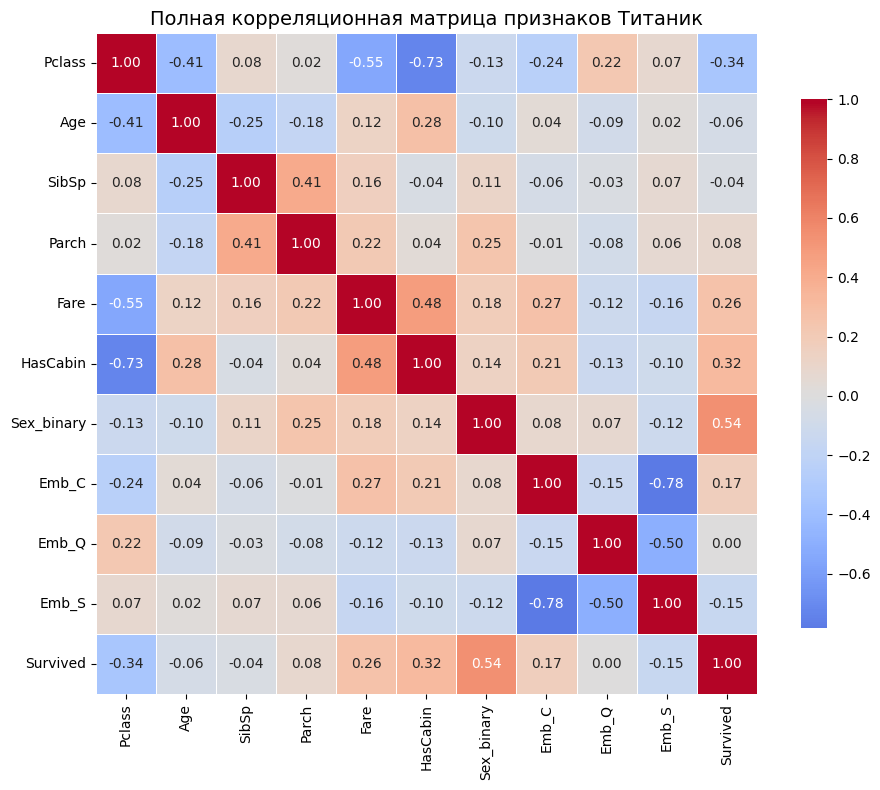

In [64]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Полная корреляционная матрица признаков Титаник', fontsize=14)
plt.tight_layout()
plt.show()

**Выводы по корреляционному анализу:**  
Признак Sex_binary является основным. Гипотеза H1 подтвердилась  
Age - слабая связь. Гипотеза пока H2 не подтвердилась, вероятно из-за нелинейности зависимости. Проведем доп анализ   
Признаки Pclass и HasCabin влияют сильно, но между ними есть мультиколлинеарность  
Признак Fare влияет значительно, но имеет умеренную связь с Pclass и HasCabin - гипотеза H3 подтвердилась  
Emb_C и Emb_S влияют умеренно, но зависимы друг от друга  
Emb_Q имеет слабую связь  
Parch, SibSp также имеют слабую связь. Гипотеза H4 не подтвердилась. В будущем стоит провести с ними конструрование признаков и доп анализ 

Проведем дополнительный анализ влияния признака Age на целевую переменную Survived

## Конструирование признаков

Согласно гипотезе H2 признак Age значительно влияет на выживаемость, но корреляционный анализ не показал этого, так как распределение выживаемости по возрасту скошено. Проверим это, создав котегориальный признак AgeGroup.

In [65]:
df_corr.to_csv('before_feature_engineering.csv')

In [3]:
df = pd.read_csv('before_feature_engineering.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   PassengerId  891 non-null    int64  
 2   Survived     891 non-null    int64  
 3   Pclass       891 non-null    int64  
 4   Name         891 non-null    object 
 5   Sex          891 non-null    object 
 6   Age          891 non-null    float64
 7   SibSp        891 non-null    int64  
 8   Parch        891 non-null    int64  
 9   Ticket       891 non-null    object 
 10  Fare         891 non-null    float64
 11  HasCabin     891 non-null    int64  
 12  Sex_binary   891 non-null    int64  
 13  Emb_C        891 non-null    int64  
 14  Emb_Q        891 non-null    int64  
 15  Emb_S        891 non-null    int64  
dtypes: float64(2), int64(11), object(3)
memory usage: 111.5+ KB


In [12]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                         labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])
age_group_survived = df.groupby('AgeGroup', observed=False)['Survived'].mean().reset_index()
print(age_group_survived)

     AgeGroup  Survived
0       Child  0.579710
1        Teen  0.428571
2  YoungAdult  0.357977
3       Adult  0.384259
4      Senior  0.227273


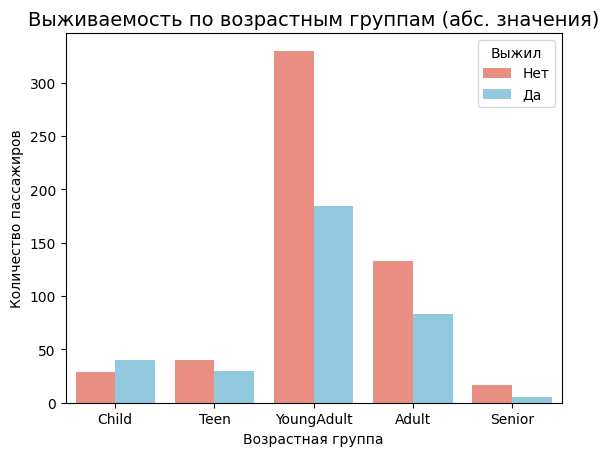

In [9]:
sns.countplot(data=df, x='AgeGroup', hue='Survived', 
              palette={0: 'salmon', 1: 'skyblue'})

# Красивые подписи
plt.title('Выживаемость по возрастным группам (абс. значения)', fontsize=14)
plt.xlabel('Возрастная группа')
plt.ylabel('Количество пассажиров')
plt.legend(title='Выжил', labels=['Нет', 'Да'])
plt.show()

По графику и средним значениям групп видно, что изначальная гипотеза была неверна: большинство детей всё таки выжило, но старые наоборот имеют худший показатель выживаемости. Тем не менее зависимость между Survived и AgeGroup определенно есть, поэтому признак следует оставить

H4, состоящая в важности SibSp и Parch для выживаемости не подтвердилась, что подозрительно. Проведем дополнительный анализ, для которого создадим признак FamilySize.   
Новая гипотеза H5: размер семьи важен для выживаемости, так как в семье могут быть дети (они выживали чаще прочих категорий), с которыми скорее всего спаслись и их матери. Одиночки в свою очередь выживали хуже, чем люди с семьями

In [14]:
df['FamilySize'] = df['SibSp'] + df['Parch']

df.groupby('FamilySize')['Survived'].mean()

FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64

Видно, что люди, у которых было на борту от 1 до 3 родственников, выживали чаще. Одиночки выживали реже, чем они. Однако люди с большими семьями выживали еще реже, что в принципе тоже логично. Признак следует оставить. Также дополнительно создадим признак IsAlone, обозначающих людей, у которых не было семьи на борту

In [15]:
df['IsAlone'] = (df['FamilySize'] == 0).astype(int)

Ранее также была оговорена возможность создать что-то новое из признака Name. Из него действительно можно было бы извлечь признак Title (титул человека). Но у него скорее всего была бы сильная корреляция как с полом, так и с уровнем богатства (Pclass, HasCabin, Fare), поэтому (по крайней мере пока) принято решение не извлекать новый признак из Title.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  HasCabin     891 non-null    int64   
 11  Sex_binary   891 non-null    int64   
 12  Emb_C        891 non-null    int64   
 13  Emb_Q        891 non-null    int64   
 14  Emb_S        891 non-null    int64   
 15  AgeGroup     891 non-null    category
 16  FamilySize   891 non-null    int64   
 17  IsAlone      891 non-null    int64   
dtypes: category(1), float64(2), in

## Повторный корреляционный анализ и отбор признаков для модели

Для начала преобразуем признак AgeGroup в тип int с помощью label encoding

In [40]:
df_corr = df.copy()

In [41]:
df_corr['AgeGroup_num'] = df_corr['AgeGroup'].map({
    'Child': 1,
    'Teen': 2,
    'YoungAdult': 3,
    'Adult': 4,
    'Senior': 5
}).astype(int)

In [42]:
df_corr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   PassengerId   891 non-null    int64   
 1   Survived      891 non-null    int64   
 2   Pclass        891 non-null    int64   
 3   Name          891 non-null    object  
 4   Sex           891 non-null    object  
 5   Age           891 non-null    float64 
 6   SibSp         891 non-null    int64   
 7   Parch         891 non-null    int64   
 8   Ticket        891 non-null    object  
 9   Fare          891 non-null    float64 
 10  HasCabin      891 non-null    int64   
 11  Sex_binary    891 non-null    int64   
 12  Emb_C         891 non-null    int64   
 13  Emb_Q         891 non-null    int64   
 14  Emb_S         891 non-null    int64   
 15  AgeGroup      891 non-null    category
 16  FamilySize    891 non-null    int64   
 17  IsAlone       891 non-null    int64   
 18  AgeGroup_n

Опираясь на прошлые наблюдения и отобрав новые признаки получаем список признаков для анализа корреляции с Survived.

In [43]:
cols_for_corr = [
    'Pclass', 'AgeGroup_num', 'FamilySize', 'IsAlone', 
    'Fare', 'HasCabin', 'Sex_binary',
    'Survived'
]
print('Колонки для корреляционного анализа: ', cols_for_corr)

Колонки для корреляционного анализа:  ['Pclass', 'AgeGroup_num', 'FamilySize', 'IsAlone', 'Fare', 'HasCabin', 'Sex_binary', 'Survived']


In [44]:
corr_matrix = df_corr[cols_for_corr].corr()
corr_with_survived = corr_matrix['Survived'].sort_values(ascending=False)
print('Корреляция с выживанием: ')
print(corr_with_survived)

Корреляция с выживанием: 
Survived        1.000000
Sex_binary      0.543351
HasCabin        0.316912
Fare            0.257307
FamilySize      0.016639
AgeGroup_num   -0.100098
IsAlone        -0.203367
Pclass         -0.338481
Name: Survived, dtype: float64


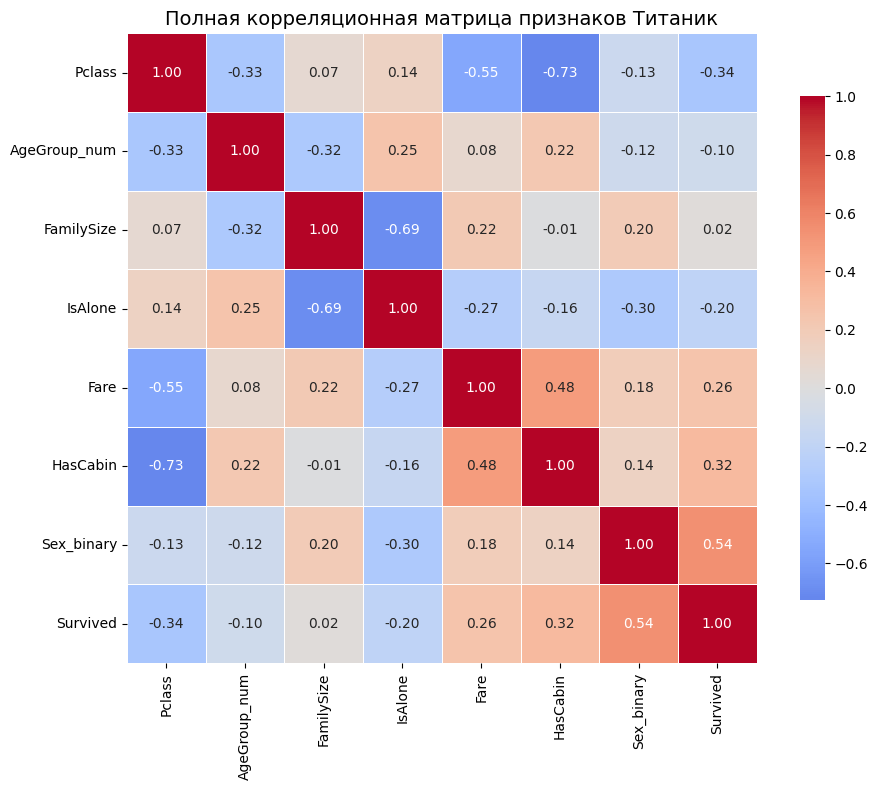

In [45]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Полная корреляционная матрица признаков Титаник', fontsize=14)
plt.tight_layout()
plt.show()

**Выводы по корреляционному анализу и отбор признаков для обучения модели:**  
Как уже говорилось, Pclass, HasCabin и Fare имеют сильную связь с Survied, но также связаны сильно связаны между собой. Для обучения я решил  **отобрать признаки: Plass и Fare**, так как среди этих трех признаков Pclass имеет самую сильную связь с Survived. Признак HasCabin отброшен из-за мультиколлинеарности с Pclass (-0.73). Fare оставил, так как корреляция с Pclass 0.55, не так критично  
**Sex_binary отобран** как основной признак, корреляция с Survuved 0.54  
**AgeGroup_num** отобран, мы видели, что возрастная группа важна для выживаемости  
Признаки FamilySize и IsAlone слишком сильно связны (-0.69). Между ними **отобран признак IsAlone**, так его легче интерпретировать

## Итоговый список признаков для модели

In [46]:
final_features = ['Pclass', 'Fare', 'Sex_binary', 'AgeGroup_num', 'IsAlone'] 
print('Итоговые признаки для обучения модели: ', final_features)

Итоговые признаки для обучения модели:  ['Pclass', 'Fare', 'Sex_binary', 'AgeGroup_num', 'IsAlone']


Создадим и сохраним матрицы с признаками и целевой переменной

In [47]:
X = df_corr[final_features]
y = df_corr['Survived']

In [48]:
X.to_csv('X_matrix.csv', index=False)
y.to_csv('y_matrix.csv', index=False)

In [49]:
X.head()

,Pclass,Fare,Sex_binary,AgeGroup_num,IsAlone
0,3,7.2500,0,3,0
1,1,71.2833,1,4,0
2,3,7.9250,1,3,1
3,1,53.1000,1,3,0
4,3,8.0500,0,3,1


In [50]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Pclass        891 non-null    int64  
 1   Fare          891 non-null    float64
 2   Sex_binary    891 non-null    int64  
 3   AgeGroup_num  891 non-null    int64  
 4   IsAlone       891 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 34.9 KB
